<a href="https://colab.research.google.com/github/robitussin/CCDATSCL_EXERCISES/blob/main/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4

This exercise focuses on data visualization and interpretation using a real-world COVID-19 dataset. The dataset contains daily records of confirmed cases, deaths, recoveries, and active cases across countries and regions, along with temporal and geographic information.
The goal of this exercise is not only to create charts, but to choose appropriate visualizations, apply correct data aggregation, and draw meaningful insights from the data. You will work with time-based, categorical, numerical, and geographic variables, and you are expected to think critically about how design choices affect interpretation.

Your visualizations should follow good practices:
- Use clear titles, axis labels, and legends
- Choose chart types appropriate to the data and question
- Avoid misleading scales or cluttered designs
- Clearly explain patterns, trends, or anomalies you observe

Unless stated otherwise, you may filter, aggregate, or group the data as needed.

<img src="https://d3i6fh83elv35t.cloudfront.net/static/2020/03/Screen-Shot-2020-03-05-at-6.29.29-PM-1024x574.png"/>

In [1]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'corona-virus-report' dataset.
Path to dataset files: /kaggle/input/corona-virus-report


In [2]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [4]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
df.query("`Country/Region` == 'Philippines'")

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
180,NaN,Philippines,12.879721,121.774017,2020-01-22,0,0,0,0,Western Pacific
441,NaN,Philippines,12.879721,121.774017,2020-01-23,0,0,0,0,Western Pacific
702,NaN,Philippines,12.879721,121.774017,2020-01-24,0,0,0,0,Western Pacific
963,NaN,Philippines,12.879721,121.774017,2020-01-25,0,0,0,0,Western Pacific
1224,NaN,Philippines,12.879721,121.774017,2020-01-26,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
47943,NaN,Philippines,12.879721,121.774017,2020-07-23,74390,1871,24383,48136,Western Pacific
48204,NaN,Philippines,12.879721,121.774017,2020-07-24,76444,1879,24502,50063,Western Pacific
48465,NaN,Philippines,12.879721,121.774017,2020-07-25,78412,1897,25752,50763,Western Pacific
48726,NaN,Philippines,12.879721,121.774017,2020-07-26,80448,1932,26110,52406,Western Pacific


## A. Time-Based Visualizations

1. Global Trend `(5 pts)`

Aggregate the data by Date and create a line chart showing the global number of confirmed COVID-19 cases over time.

In [19]:
import altair as alt

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate data by Date and sum confirmed cases
global_cases = df.groupby('Date')['Confirmed'].sum().reset_index()

# Create the line chart
chart = alt.Chart(global_cases).mark_line().encode(
    x=alt.X('Date', axis=alt.Axis(title='Date')),
    y=alt.Y('Confirmed', axis=alt.Axis(title='Global Confirmed Cases')),
    tooltip=[alt.Tooltip('Date'), alt.Tooltip('Confirmed', format=',')]
).properties(
    title='Global Confirmed COVID-19 Cases Over Time'
).interactive()

chart

alt.Chart(...)

2. Country-Level Trends `(5 pts)`

Select three countries and visualize their confirmed case counts over time on the same plot.

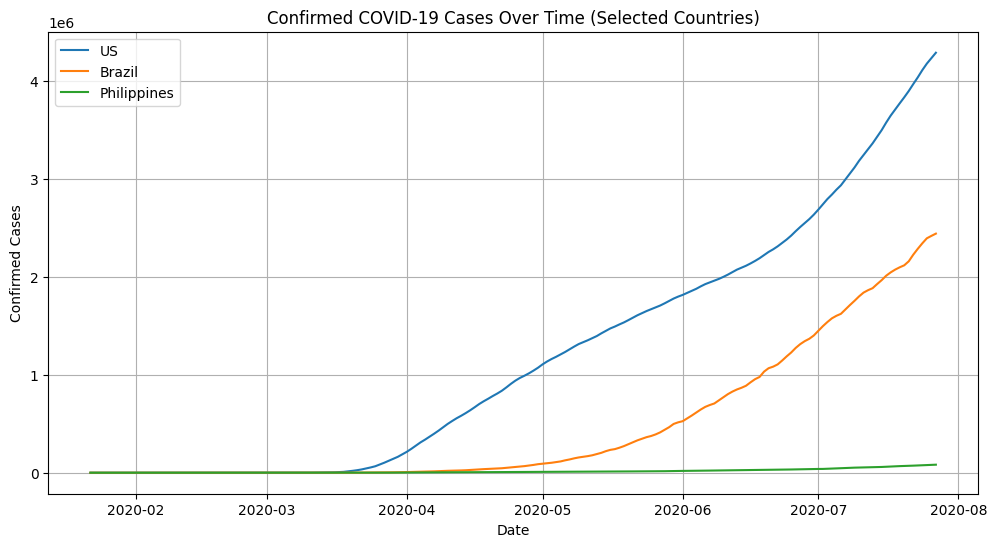

In [25]:
import matplotlib.pyplot as plt



# Aggregate data by Date and sum confirmed cases
global_cases = df.groupby('Date')['Confirmed'].sum().reset_index()
global_cases

top_confirmed_countries = df.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(3)

top_confirmed_countries


countries = ['US', 'Brazil', 'Philippines']

country_df = df[df['Country/Region'].isin(countries)]

plt.figure(figsize=(12,6))

for country in countries:
    temp = country_df[country_df['Country/Region'] == country]
    plt.plot(temp['Date'], temp['Confirmed'], label=country)

plt.title('Confirmed COVID-19 Cases Over Time (Selected Countries)')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.legend()
plt.grid(True)
plt.show()



3. Active vs Recovered `(5 pts)`

For a selected country, create a line chart showing Active and Recovered cases over time.

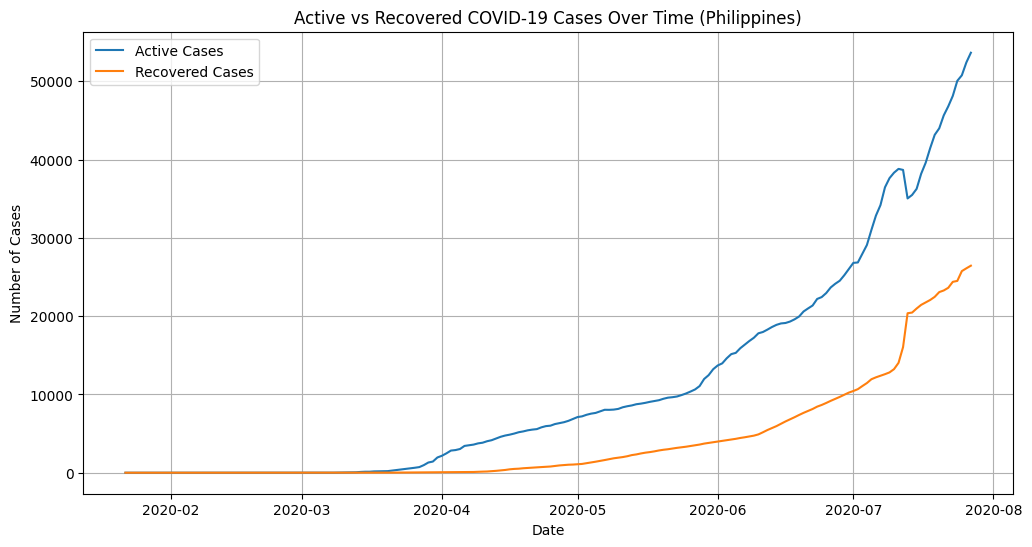

In [24]:

# put your answer here

country = 'Philippines'
country_df = df[df['Country/Region'] == country]

plt.figure(figsize=(12,6))

plt.plot(country_df['Date'], country_df['Active'], label='Active Cases')
plt.plot(country_df['Date'], country_df['Recovered'], label='Recovered Cases')

plt.title(f'Active vs Recovered COVID-19 Cases Over Time ({country})')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.show()

## B: Comparative Visualizations

4. Country Comparison `(5 pts)`

Using data from a single date, create a bar chart showing the top 10 countries by confirmed cases.

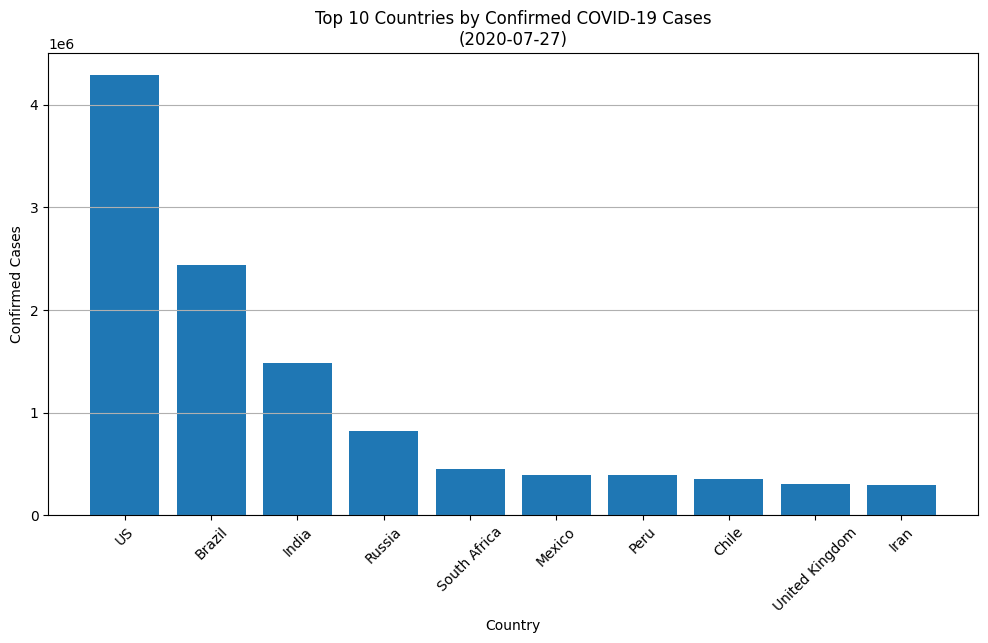

In [26]:
# put your answer here

df['Date'] = pd.to_datetime(df['Date'])

# Select a single date (latest date in the dataset)
selected_date = df['Date'].max()

# Filter data for the selected date
date_df = df[df['Date'] == selected_date]

# Group by country and get confirmed cases
top10 = (
    date_df
    .groupby('Country/Region')['Confirmed']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(top10.index, top10.values)
plt.title(f'Top 10 Countries by Confirmed COVID-19 Cases\n({selected_date.date()})')
plt.xlabel('Country')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

5. WHO Region Comparison `(5 pts)`

Aggregate confirmed cases by WHO Region and visualize the result using a bar chart.

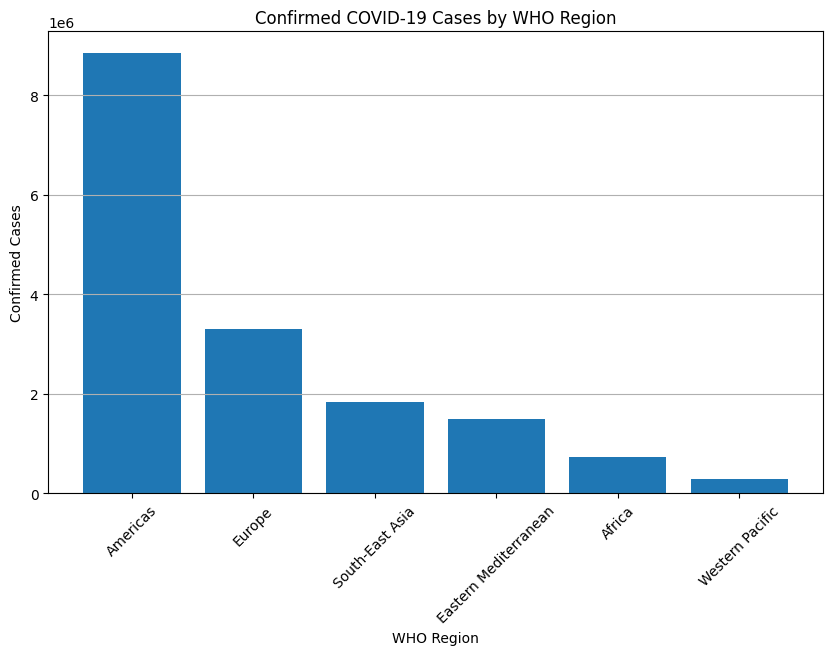

In [27]:

# put your answer here
df['Date'] = pd.to_datetime(df['Date'])

latest_date = df['Date'].max()
latest_df = df[df['Date'] == latest_date]

region_cases = (
    latest_df
    .groupby('WHO Region')['Confirmed']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
plt.bar(region_cases.index, region_cases.values)
plt.title('Confirmed COVID-19 Cases by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## C. Geographic Visualization

6. Geographic Spread `(10 pts)`

Using Latitude and Longitude, create a map-based visualization showing confirmed cases for a selected date.

In [28]:

# put your answer here

import pandas as pd
import plotly.express as px

df['Date'] = pd.to_datetime(df['Date'])

selected_date = df['Date'].max()
date_df = df[df['Date'] == selected_date]

fig = px.scatter_geo(
    date_df,
    lat='Lat',
    lon='Long',
    size='Confirmed',
    color='Confirmed',
    hover_name='Country/Region',
    size_max=40,
    projection='natural earth',
    title=f'Geographic Spread of Confirmed COVID-19 Cases ({selected_date.date()})'
)

fig.show()


7. Regional Clustering `(15 pts)`

Create a visualization that shows how confirmed cases are distributed geographically within a single WHO Region.

In [29]:

# put your answer here
import pandas as pd
import plotly.express as px

df['Date'] = pd.to_datetime(df['Date'])

asia_regions = ['Eastern Mediterranean', 'South-East Asia', 'Western Pacific']

selected_date = df['Date'].max()

asia_df = df[(df['WHO Region'].isin(asia_regions)) & (df['Date'] == selected_date)]

fig = px.scatter_geo(
    asia_df,
    lat='Lat',
    lon='Long',
    size='Confirmed',
    color='Confirmed',
    hover_name='Country/Region',
    projection='natural earth',
    size_max=40,
    title=f'Geographic Distribution of Confirmed COVID-19 Cases in Asia ({selected_date.date()})'
)

fig.show()

# Task
Identify the top 10 countries by total confirmed COVID-19 cases on the latest available date and create a multi-line chart visualizing their confirmed case trends over time.

## Identify Top Countries

### Subtask:
Determine the top 10 countries based on their total confirmed cases on the latest available date.


**Reasoning**:
First, I need to identify the latest date available in the dataset to filter the data correctly for the top 10 countries comparison.



In [30]:
latest_date = df['Date'].max()
print(f"The latest date in the dataset is: {latest_date.strftime('%Y-%m-%d')}")

df_latest_date = df[df['Date'] == latest_date]


The latest date in the dataset is: 2020-07-27


**Reasoning**:
Now that the data for the latest date has been filtered, I will group it by country, sum the confirmed cases, sort them in descending order, and extract the names of the top 10 countries.



In [31]:
country_cases_latest = df_latest_date.groupby('Country/Region')['Confirmed'].sum().reset_index()
top_10_countries = country_cases_latest.sort_values(by='Confirmed', ascending=False).head(10)
top_10_country_names = top_10_countries['Country/Region'].tolist()

print("Top 10 countries by confirmed cases on the latest date:")
print(top_10_countries)
print("\nList of top 10 country names:", top_10_country_names)

Top 10 countries by confirmed cases on the latest date:
     Country/Region  Confirmed
173              US    4290259
23           Brazil    2442375
79            India    1480073
138          Russia     816680
154    South Africa     452529
111          Mexico     395489
132            Peru     389717
35            Chile     347923
177  United Kingdom     301708
81             Iran     293606

List of top 10 country names: ['US', 'Brazil', 'India', 'Russia', 'South Africa', 'Mexico', 'Peru', 'Chile', 'United Kingdom', 'Iran']


## Filter Data for Selected Countries

### Subtask:
Filter the original DataFrame to include only the time-series data for the identified top countries.


**Reasoning**:
I need to filter the original DataFrame `df` to include only the rows corresponding to the countries in the `top_10_country_names` list, as specified in the instructions. This will create a new DataFrame `df_top_10_countries` containing the time-series data for these top countries.



In [32]:
df_top_10_countries = df[df['Country/Region'].isin(top_10_country_names)]

print("Shape of the filtered DataFrame:", df_top_10_countries.shape)
print("Countries in the filtered DataFrame:", df_top_10_countries['Country/Region'].unique())

Shape of the filtered DataFrame: (3760, 10)
Countries in the filtered DataFrame: ['Brazil' 'Chile' 'India' 'Iran' 'Mexico' 'Peru' 'Russia' 'South Africa'
 'United Kingdom' 'US']


## Create Line Chart

### Subtask:
Generate a multi-line chart using Altair, showing the confirmed case trends over time for each of the selected top countries on a single plot.


In [38]:
Top_10_country_cases_latest = df_latest_date.groupby('Country/Region')['Confirmed'].sum().reset_index()
top_10_countries = country_cases_latest.sort_values(by='Confirmed', ascending=False).head(10)


top_10_country_names = top_10_countries['Country/Region'].tolist()

df_top_10 = df[df['Country/Region'].isin(top_10_country_names)]

import altair as alt

chart = alt.Chart(df_top_10).mark_line().encode(
    x=alt.X('Date:T', title='Date'),
    y=alt.Y('Confirmed:Q', title='Confirmed Cases'),
    color='Country/Region:N',
    tooltip=['Country/Region', 'Date', 'Confirmed']
).properties(
    title='Top 10 Countries by Confirmed COVID-19 Cases Over Time'
)

chart


alt.Chart(...)

## Summary:

### Q&A
The top 10 countries by total confirmed COVID-19 cases on the latest available date (July 27, 2020) have been identified.

### Data Analysis Key Findings
*   The latest date available in the dataset is July 27, 2020.
*   The top 10 countries by total confirmed cases on July 27, 2020, are:
    *   US: 4,290,259
    *   Brazil: 2,442,375
    *   India: 1,480,073
    *   Russia: 816,680
    *   South Africa: 452,529
    *   Mexico: 395,489
    *   Peru: 389,717
    *   Chile: 347,923
    *   United Kingdom: 301,708
    *   Iran: 293,606
*   A new DataFrame, `df_top_10_countries`, was successfully created, containing time-series data for these top 10 countries, with a shape of (3760, 10).

### Insights or Next Steps
*   The next step is to generate a multi-line chart using Altair to visualize the confirmed case trends over time for these identified top 10 countries.
